# ODMR: load saved arrays → plot → fit

This notebook is analysis-only:

- Load the saved `data.json` + `arrays.npz` (DataHandler format)
- Plot the raw arrays and normalized ODMR
- Fit the resonance (works for CW and pulsed datasets)

## 1) Imports + locate NV2_array

In [247]:
from __future__ import annotations
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

def find_workspace_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / 'experiment-main').exists():
            return p
    raise RuntimeError('Could not find workspace root containing experiment-main')

WORKSPACE = find_workspace_root(Path.cwd())
NV2 = (WORKSPACE / "qua-libs/Quantum-Control-Applications/Optically addressable spin qubits/NV2_array_sprout").resolve()
sys.path.insert(0, str(WORKSPACE / 'experiment-main'))
from qua_tools_nv2.dataset import DatasetReader
from qua_tools_nv2.nv2_fits import Fitter

CC_NS = 4.0

## 2) Load saved arrays

In [248]:
# Toggle whether to use LO frequency (absolute MW freq) or just IF
USE_LO_FREQUENCY = False  # Set False to work in IF space

reader = DatasetReader(nv_root=NV2)
DATA_ROOT = reader.data_root
EXPERIMENT_TAG = 'odmr'  # matches folder names like '#1_cw_odmr_...' or '#24_pulsed_odmr_...'
# Choose a specific dataset folder or leave None for latest matching tag:
#DATASET = r'2026-06-23\#624_pulsed_odmr_gradient_153529'
# DATASET = r'C:\\\\...\\\\NV2_array\\\\Data\\\\2025-12-31\\\\#1_cw_odmr_122033'
DATASET = None

# Fit mode: 'single' for one Lorentzian dip, 'double' for two (e.g. split by axial B-field)
FIT_MODE = 'single'  # 'single' or 'double'

def find_latest_by_tag(tag: str) -> Path:
    candidates = [p.parent for p in DATA_ROOT.rglob('data.json') if p.is_file() and tag in p.parent.name.lower()]
    if not candidates:
        raise FileNotFoundError(f"No datasets matching tag {tag!r} under {DATA_ROOT}")
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]

ds_folder = find_latest_by_tag(EXPERIMENT_TAG) if DATASET is None else reader.resolve_dataset(DATASET).folder
ds = reader.resolve_dataset(ds_folder)
data = reader.load(ds)

if_hz = np.asarray(data['IF_frequencies'], dtype=float)
counts_data = np.asarray(data['counts_data'], dtype=float)
counts_ref_data = np.asarray(data['counts_ref_data'], dtype=float)

cfg = data.get('config') or {}
if USE_LO_FREQUENCY:
    lo_hz = float(cfg['elements']['NV']['mixInputs']['lo_frequency'])
    f_mw_hz = lo_hz + if_hz
else:
    lo_hz = None
    f_mw_hz = if_hz

pulses = cfg.get('pulses') or {}
readout_len_ns = float(pulses['readout_pulse_2']['length']) #fix for CW-odmr
meas_len_s = readout_len_ns * 1e-9

signal_kcps = counts_data / 1000.0 / meas_len_s
ref_kcps = counts_ref_data / 1000.0 / meas_len_s

with np.errstate(divide='ignore', invalid='ignore'):
    contrast = 1- (ref_kcps - signal_kcps) / ref_kcps

print(f'Loaded: {ds.folder.relative_to(DATA_ROOT)}')
print(f'Fit mode: {FIT_MODE}')

Loaded: 2026-06-29\#631_pulsed_odmr_182150
Fit mode: single


## 3) Plot original arrays

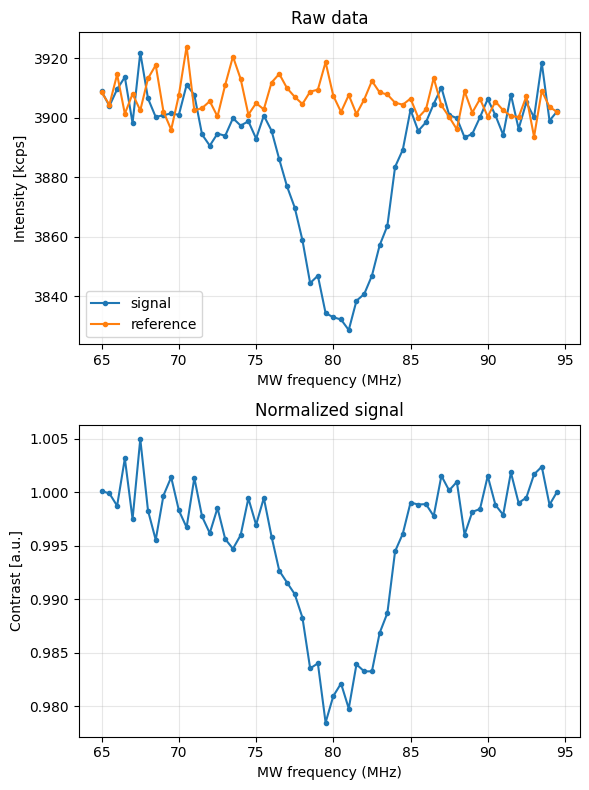

In [249]:
fig, ax = plt.subplots(2, 1, figsize=(6, 8))

ax[0].plot(f_mw_hz / 1e6, signal_kcps, 'o-', ms=3, label='signal')
ax[0].plot(f_mw_hz / 1e6, ref_kcps, 'o-', ms=3, label='reference')
ax[0].set_xlabel('MW frequency (MHz)')
ax[0].set_ylabel('Intensity [kcps]')
ax[0].set_title('Raw data')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(f_mw_hz / 1e6, contrast, 'o-', ms=3)
ax[1].set_xlabel('MW frequency (MHz)')
ax[1].set_ylabel('Contrast [a.u.]')
ax[1].set_title('Normalized signal')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4) Fit

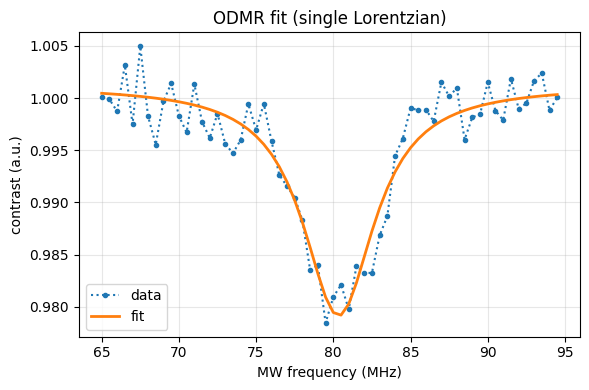

f0       = 80.3410 ± 0.1363 MHz
FWHM     = 5.6597 ± 0.5436 MHz
amp      = -0.0220 ± 0.0011
baseline = 1.0012 ± 0.0005


In [250]:
fitter = Fitter()

if FIT_MODE == 'double':
    res = fitter.double_lorentzian(f_mw_hz, contrast)
else:
    res = fitter.lorentzian(f_mw_hz, contrast)

plt.figure(figsize=(6, 4))
plt.plot(f_mw_hz / 1e6, contrast, ':o', ms=3, label='data')
plt.plot(f_mw_hz / 1e6, res.y_fit, '-', lw=2, label='fit')
plt.xlabel('MW frequency (MHz)')
plt.ylabel('contrast (a.u.)')
plt.title(f'ODMR fit ({FIT_MODE} Lorentzian)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

p = res.params
if FIT_MODE == 'double':
    print(f"Peak 1:  f0 = {p['x01']/1e6:.4f} ± {p['x01_err']/1e6:.4f} MHz,  FWHM = {p['fwhm1']/1e6:.4f} MHz,  amp = {p['amp1']:.4f}")
    print(f"Peak 2:  f0 = {p['x02']/1e6:.4f} ± {p['x02_err']/1e6:.4f} MHz,  FWHM = {p['fwhm2']/1e6:.4f} MHz,  amp = {p['amp2']:.4f}")
    print(f"Split:   {p['split']/1e6:.4f} MHz")
    print(f"Baseline: {p['baseline']:.4f}")
else:
    print(f"f0       = {p['x0']/1e6:.4f} ± {p['x0_err']/1e6:.4f} MHz")
    print(f"FWHM     = {p['fwhm']/1e6:.4f} ± {p['fwhm_err']/1e6:.4f} MHz")
    print(f"amp      = {p['amp']:.4f} ± {p['amp_err']:.4f}")
    print(f"baseline = {p['baseline']:.4f} ± {p['baseline_err']:.4f}")

In [251]:
resid_rms = np.sqrt(np.mean((res.y - res.y_fit) ** 2))
if FIT_MODE == 'double':
    amp_ref = max(abs(res.params['amp1']), abs(res.params['amp2']))
else:
    amp_ref = abs(res.params['amp'])
SNR = amp_ref / resid_rms if resid_rms > 0 else np.inf
print(f"Residual RMS: {resid_rms:.4g}")
print(f"SNR:          {SNR:.2f}")

Residual RMS: 0.002163
SNR:          10.19
